<a href="https://colab.research.google.com/github/piyushdange/handwritten-digit-recognition/blob/main/handwrittendigit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import files
uploaded = files.upload()

Saving HANDWRITTEN DIGITS DATASET.zip to HANDWRITTEN DIGITS DATASET (1).zip


In [31]:
import zipfile

with zipfile.ZipFile("HANDWRITTEN DIGITS DATASET.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("✅ Dataset Extracted")

✅ Dataset Extracted


In [45]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [46]:
data = []
labels = []

base_path = "HANDWRITTEN DIGITS DATASET"

# Iterate directly over the files in the base_path
for file_name in os.listdir(base_path):
    if file_name.endswith(('.jpeg', '.png', '.jpg')):
        try:
            # Extract label from filename (e.g., '9' from '9_10.jpeg')
            label = int(file_name.split('_')[0])
        except ValueError:
            print(f"Skipping file with unparsable label: {file_name}")
            continue

        path = os.path.join(base_path, file_name)

        img = cv2.imread(path)
        if img is None:
            print(f"Warning: Could not read image {path}. Skipping.")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = 255 - gray   # invert

        _, gray = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

        resized = cv2.resize(gray, (28,28))
        normalized = resized / 255.0

        data.append(normalized)
        labels.append(label)

data = np.array(data).reshape(-1,28,28,1)
labels = np.array(labels)

print("✅ Data Loaded:", data.shape)

✅ Data Loaded: (100, 28, 28, 1)


In [47]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(data, labels, epochs=15)

print("✅ Training Done")

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1200 - loss: 2.2985
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1800 - loss: 2.1916
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2400 - loss: 2.0815
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3700 - loss: 1.9761
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3400 - loss: 1.8858
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5400 - loss: 1.7075
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5800 - loss: 1.5473
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5700 - loss: 1.3887
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5700 - loss: 1.2848
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6300 - loss: 1.1642
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6800 - loss: 1.0679
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6800 - loss: 0.9700
E

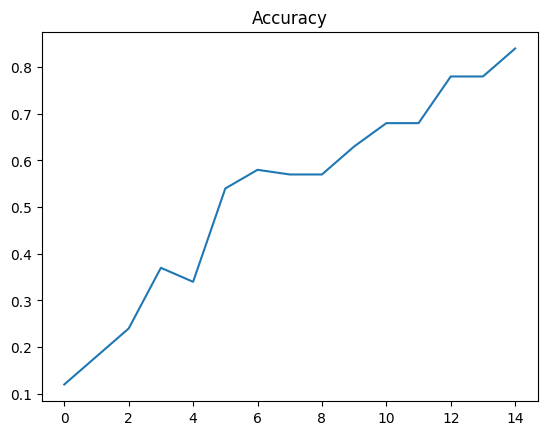

In [49]:
plt.plot(history.history['accuracy'])
plt.title("Accuracy")
plt.show()

In [40]:
from google.colab import files
uploaded = files.upload()

Saving 6_5.jpeg to 6_5.jpeg


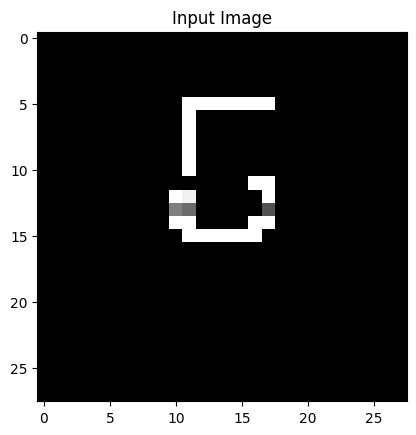

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
👉 Predicted Digit: 6


In [41]:
img = cv2.imread(list(uploaded.keys())[0])

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = 255 - gray
_, gray = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

resized = cv2.resize(gray, (28,28))
normalized = resized / 255.0
reshaped = normalized.reshape(1,28,28,1)

plt.imshow(resized, cmap='gray')
plt.title("Input Image")
plt.show()

prediction = model.predict(reshaped)
print("👉 Predicted Digit:", np.argmax(prediction))

In [42]:
#live demo
!pip install gradio

In [50]:
#live demo
import gradio as gr

def predict_digit(img):
    img = np.array(img)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = 255 - gray
    _, gray = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    resized = cv2.resize(gray, (28,28))
    normalized = resized / 255.0
    reshaped = normalized.reshape(1,28,28,1)

    prediction = model.predict(reshaped)
    return f"Predicted Digit: {np.argmax(prediction)}"

interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Image(type="numpy"),
    outputs="text",
    title="Handwritten Digit Recognition"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45fe68c4afd36d871f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
